# IMPORTS

## Deep Learning & Core API

In [1]:
import tensorflow as tf                     
from tensorflow import keras               
from tensorflow.keras import layers, regularizers
from tensorflow.keras import backend as K   

2025-08-21 06:36:12.206994: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-21 06:36:12.207041: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-21 06:36:12.208962: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-21 06:36:12.217092: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Data Handling & Augmentation

In [2]:
import numpy as np                         
import pandas as pd                         
from sklearn.utils import shuffle           
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Metrics

In [3]:
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score
)

## Plotting

In [4]:
import matplotlib.pyplot as plt
plt.style.use("default")

## Image Ops

In [5]:
!pip install opencv-python-headless --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
matplotlib 3.8.2 requires numpy<2,>=1.21, but you have numpy 2.2.6 which is incompatible.
tensorflow 2.15.0 requires numpy<2.0.0,>=1.23.5, but you have numpy 2.2.6 which is incompatible.

[notice] A new release of pip is available: 23.3.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [6]:
import cv2
print(cv2.__version__)

4.12.0


## Experiment Tracking & Env

In [7]:
from comet_ml import Experiment
from dotenv import load_dotenv

## System & Utilities

In [8]:
import os, shutil, datetime, random

# GPU Settings

In [9]:
# List all physical devices available to TensorFlow (CPUs, GPUs, etc.)
devices = tf.config.list_physical_devices()
print("Devices:", devices)

# Query for the default GPU device name (if any)
device_name = tf.test.gpu_device_name()
# If TensorFlow did not detect a GPU at '/device:GPU:0', raise an error
if device_name != '/device:GPU:0':
    raise SystemError('GPU device not found')
# Confirm that the GPU was found
print('Found GPU at: {}'.format(device_name))

# Set the default device context to the GPU for subsequent ops
tf.device('/device:GPU:0')

Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found GPU at: /device:GPU:0


2025-08-21 06:36:22.589439: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /device:GPU:0 with 79078 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:24:00.0, compute capability: 8.0
2025-08-21 06:36:22.596754: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79078 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:24:00.0, compute capability: 8.0


# Comet Experiment

In [10]:
# Initialize a Comet.ml experiment for tracking metrics, parameters, and model artifacts.
experiment = Experiment(
    api_key=os.getenv("COMET_API_KEY"),         # Your Comet API key stored in an environment variable
    project_name="multi_modal_development",     # Name of the Comet project this experiment belongs to
    auto_histogram_weight_logging=True,         # Automatically log weight distributions after each epoch
    auto_histogram_gradient_logging=True,       # Automatically log gradient distributions after each epoch
    auto_histogram_activation_logging=True,     # Automatically log layer activation distributions after each epoch
)

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: tensorboard, keras, tensorflow, sklearn.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Couldn't find a Git repository in '/app' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.
COMET INFO: Experiment is live on comet.com https://www.comet.com/anabiosi-data/multi-modal-development/308fd1e5d4e2462b9ed206ad34315287



# Directory Setup

In [11]:
# Retrieve the previously logged dataset artifact named "elastography_images" from Comet.ml
logged_artifact = experiment.get_artifact("elastography_images_merged")

# If we haven't already downloaded the images locally, download them now
if not os.path.exists("./Elastography_images"):
    # Download the artifact into the current directory (creates "./Elastography_images" folder)
    local_artifact = logged_artifact.download("./")

COMET INFO: Artifact 'anabiosi-data/elastography_images_merged:6.0.0' download has been started asynchronously
COMET INFO: Still downloading 1598 file(s), remaining 722.63 MB/722.63 MB
COMET INFO: Still downloading 1589 file(s), remaining 718.51 MB/722.63 MB, Throughput 281.15 KB/s, ETA ~2617s
COMET INFO: Artifact 'anabiosi-data/elastography_images_merged:6.0.0' has been successfully downloaded


In [12]:
# Set a fixed random seed for reproducibility (e.g., shuffling, augmentations)
seed = 42

# Retrieve the list of class names from the downloaded artifact's metadata
class_names = logged_artifact.metadata["classes"]

# Create an ImageDataGenerator and point it at the local image folder
dataset = ImageDataGenerator().flow_from_directory(
    './Elastography_images',       # Directory containing subfolders per class
    batch_size=1579,               # Load all images in one batch
    class_mode='sparse',           # Return integer labels rather than one‑hot vectors
    target_size=(300, 400),        # Resize every image to 300×400 pixels
    shuffle=False,                 # Keep original ordering (we'll shuffle manually if needed)
    classes=class_names            # Use the provided list of class names (ensures consistent mapping)
)

# Explicitly place data loading on the GPU (if supported and desired)
with tf.device('/device:GPU:0'):
    x, y = dataset.next()         # Load one full batch of (images, labels)

# Report what classes we're working with and how many samples we loaded
print("Classes:", class_names)
print(f"We have {x.shape[0]} total observations")

Found 1578 images belonging to 3 classes.
Classes: ['response', 'stable', 'non-response']
We have 1578 total observations


In [13]:
!pip install openpyxl -q


[notice] A new release of pip is available: 23.3.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [14]:
# point at the Excel file
excel_path = './clustering_all_v5.xlsx' 

# read it in
df = pd.read_excel(excel_path)

# Quick sanity check: see the first few rows
print(df.head())
df

                                         name  Respone/stable/non-Response  \
0  4T1 LOOK DAY29_1C1_1A_b_cropped_square.tif                            1   
1  4T1 LOOK DAY29_1C1_1A_c_cropped_square.tif                            1   
2    4T1 LOOK DAY29_1C1_1A_cropped_square.tif                            1   
3  4T1 LOOK DAY29_1C1_1D_c_cropped_square.tif                            1   
4    4T1 LOOK DAY29_1C1_1D_cropped_square.tif                            1   

   Elastic Modulus SWE (kPa)  Perfused Area  Cell lines Type of Cancer  \
0                  34.641412        0.624986        4T1         Breast   
1                  23.514638        0.624986        4T1         Breast   
2                  20.450058        0.624986        4T1         Breast   
3                  29.826093        0.793898        4T1         Breast   
4                  22.371027        0.793898        4T1         Breast   

   Therapy  final dimensions  x  final dimensions  y  final dimensions  z  \
0      4.

,name,Respone/stable/non-Response,Elastic Modulus SWE (kPa),Perfused Area,Cell lines,Type of Cancer,Therapy,final dimensions x,final dimensions y,final dimensions z,...,relative volume,stress kPa from comsol,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,4T1 LOOK DAY29_1C1_1A_b_cropped_square.tif,1,34.641412,0.624986,4T1,Breast,4.0,8.04,4.30,7.34,...,0.683167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4T1 LOOK DAY29_1C1_1A_c_cropped_square.tif,1,23.514638,0.624986,4T1,Breast,4.0,6.94,4.71,6.20,...,0.419400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,chemotherapy
2,4T1 LOOK DAY29_1C1_1A_cropped_square.tif,1,20.450058,0.624986,4T1,Breast,4.0,8.52,3.70,4.97,...,0.440482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,immunotherapy
3,4T1 LOOK DAY29_1C1_1D_c_cropped_square.tif,1,29.826093,0.793898,4T1,Breast,6.0,7.05,5.32,7.06,...,1.025683,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,chemotherapy +immunotherapy
4,4T1 LOOK DAY29_1C1_1D_cropped_square.tif,1,22.371027,0.793898,4T1,Breast,6.0,8.93,3.78,5.27,...,0.452299,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,mechanotheraptutics +chemotherapy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1573,CT_13_M2NR.tif,2,42.410000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1574,CT_14_M2NR.tif,2,42.410000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1575,CT_15_M2NR.tif,2,38.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1576,CT_16_M2NR.tif,2,39.030000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
df_small = df[['name', 'Elastic Modulus SWE (kPa)']].copy()

In [16]:
## Now refer to them as df_small.filename and df_small.elastic_modulus_kpa, which is shorter and clearer.
df_small.rename(
    columns={
      'name': 'filename',
      'Elastic Modulus SWE (kPa)': 'elastic_modulus_kpa'
    },
    inplace=True
)

# fix in-place:
df_small['filename'] = df_small['filename'].str.replace('\u03A4', 'T')

In [17]:
df_small

,filename,elastic_modulus_kpa
0,4T1 LOOK DAY29_1C1_1A_b_cropped_square.tif,34.641412
1,4T1 LOOK DAY29_1C1_1A_c_cropped_square.tif,23.514638
2,4T1 LOOK DAY29_1C1_1A_cropped_square.tif,20.450058
3,4T1 LOOK DAY29_1C1_1D_c_cropped_square.tif,29.826093
4,4T1 LOOK DAY29_1C1_1D_cropped_square.tif,22.371027
...,...,...
1573,CT_13_M2NR.tif,42.410000
1574,CT_14_M2NR.tif,42.410000
1575,CT_15_M2NR.tif,38.500000
1576,CT_16_M2NR.tif,39.030000


# Quality Checks

In [18]:
# Sanity‐check shapes
print(f"x.shape      = {x.shape}")   # e.g. (1365, 300, 400, 3)
print(f"y.shape      = {y.shape}")   # e.g. (1365,)
print(f"n filenames  = {len(dataset.filenames)}")

x.shape      = (1578, 300, 400, 3)
y.shape      = (1578,)
n filenames  = 1578


In [19]:
# Peek at the first 5 filenames and their labels
print("\nFirst 5 samples:")
for i in range(5):
    fn = dataset.filenames[i]
    print(f"  idx={i:3d}: file='{fn}',  y={y[i]}")


First 5 samples:
  idx=  0: file='response/4T1 LOOK DAY29_1C1_1A_b_cropped_square.tif',  y=0.0
  idx=  1: file='response/4T1 LOOK DAY29_1C1_1A_c_cropped_square.tif',  y=0.0
  idx=  2: file='response/4T1 LOOK DAY29_1C1_1A_cropped_square.tif',  y=0.0
  idx=  3: file='response/4T1 LOOK DAY29_1C1_1D_c_cropped_square.tif',  y=0.0
  idx=  4: file='response/4T1 LOOK DAY29_1C1_1D_cropped_square.tif',  y=0.0


In [20]:
# Check every filename is in your Excel lookup
excel_files = set(df_small['filename'])
missing = [fn for fn in dataset.filenames if fn not in excel_files]
print(f"\nLookup check: {len(missing)} filenames NOT in df_small:")
print(missing[:10])  # show up to first 10 missing, if any


Lookup check: 1578 filenames NOT in df_small:
['response/4T1 LOOK DAY29_1C1_1A_b_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1A_c_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1A_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1D_c_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1D_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2A_b_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2A_c_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2A_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2D_b_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2D_c_cropped_square.tif']


# Combining the images with the numerical data

In [21]:
# Get the exact file‐order that produced x and y

files_in_order = dataset.filenames
print(files_in_order[:10])

['response/4T1 LOOK DAY29_1C1_1A_b_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1A_c_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1A_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1D_c_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1D_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2A_b_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2A_c_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2A_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2D_b_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2D_c_cropped_square.tif']


 This line gets a list of the full file paths of all the images that ImageDataGenerator loaded into your x numpy array. The key here is that this list is in the exact same order as the images are arranged in the x array. This list is your reference for the image order.

In [22]:
# Drop the class prefix to match your Excel keys

basenames = [os.path.basename(p) for p in files_in_order]

Your Excel file's 'name' column likely contains just the filename without the directory structure (like 'response/' or 'stable/'). This line uses os.path.basename() to strip off that directory prefix from each file path in files_in_order. The basenames list now contains just the filenames, and critically, it's still in the same order as the images in x and the labels in y.

In [23]:
# Build filename → kPa lookup from df_small

num_map = dict(zip(
    df_small['filename'],
    df_small['elastic_modulus_kpa']
))

This creates a Python dictionary. It takes the 'filename' column from your df_small DataFrame (which contains the base filenames from your Excel data) and pairs each filename with its corresponding 'elastic_modulus_kpa' value. This dictionary acts as a quick lookup table: you can give it a filename, and it returns the Elastic Modulus for that file according to your Excel data.

In [24]:
# Create X_num in the same sequence as x, y
X_num = np.array([num_map[b] for b in basenames],
                 dtype=np.float32).reshape(-1, 1)

# Verify shapes all match
assert x.shape[0] == X_num.shape[0] == y.shape[0], \
    f"Shape mismatch: x={x.shape[0]}, X_num={X_num.shape[0]}, y={y.shape[0]}"

# Spot-check a few samples
for i in [0, 10, 100, 500, 698, 748]:
    fname = basenames[i]
    print(f"idx={i:3d}:")
    print("  file:", fname)
    print("  label:", y[i])
    print("  numeric (kPa):", X_num[i,0])
    print("  expected kPa from df_small:", num_map[fname])
    print("---")

idx=  0:
  file: 4T1 LOOK DAY29_1C1_1A_b_cropped_square.tif
  label: 0.0
  numeric (kPa): 34.64141
  expected kPa from df_small: 34.6414115585445
---
idx= 10:
  file: 4T1 LOOK DAY29_1C1_2D_cropped_square.tif
  label: 0.0
  numeric (kPa): 31.362246
  expected kPa from df_small: 31.3622458206534
---
idx=100:
  file: 4T1-BOSENTAN 10-CAGE101A_cropped_square.tif
  label: 0.0
  numeric (kPa): 28.774137
  expected kPa from df_small: 28.7741366905846
---
idx=500:
  file: E0771_TRAN_MIC_DAY14C5_2D_b_cropped_square.tif
  label: 0.0
  numeric (kPa): 24.397993
  expected kPa from df_small: 24.3979927820739
---
idx=698:
  file: 4T1-BOSENTA_IMM_-IMMUNOC5_NONE_c_cropped_square.tif
  label: 1.0
  numeric (kPa): 32.10513
  expected kPa from df_small: 32.1051289621743
---
idx=748:
  file: B6-BOSENTA _IMM_ CONTROLC2_1A_cropped_square.tif
  label: 1.0
  numeric (kPa): 47.269875
  expected kPa from df_small: 47.2698756948572
---


X_num = np.array([num_map[b] for b in basenames], dtype=np.float32).reshape(-1, 1): This is the core alignment step. It iterates through the basenames list (which is in the correct order matching x and y). For each filename b in this list, it uses the num_map dictionary to retrieve the associated elastic_modulus_kpa value from your Excel data. These retrieved numerical values are collected into a new list, which is then converted into a numpy array X_num. Because we iterated through basenames (which is aligned with x and y), the X_num array is now also aligned with x and y. reshape(-1, 1) just ensures the numerical data is in the correct 2D shape expected for a single numerical feature input (num_samples, 1).
Assertions and Spot-checks: The assert statement programmatically confirms that the number of samples in your image array (x), the newly created numerical array (X_num), and your label array (y) are all the same. This is a vital check that the alignment process didn't lose or duplicate samples. The spot-check loop then allows you to manually inspect a few samples, printing the filename, label (from y), the numerical value you just put into X_num, and the expected numerical value directly from your Excel lookup (num_map[fname]). If these match for the checked indices, it gives you high confidence that the alignment is correct.

# CHECKS

## Shape check — makes sure you have exactly one numeric value and one label per image.

In [25]:
# SHAPE CHECK — every image must have a numeric value and a label
print("Shape of x:",      x.shape)
print("Shape of X_num:",  X_num.shape)
print("Shape of y:",      y.shape)
assert x.shape[0] == X_num.shape[0] == y.shape[0], "❌ Mismatch in sample counts!"

Shape of x: (1578, 300, 400, 3)
Shape of X_num: (1578, 1)
Shape of y: (1578,)


## Missing‐key check — ensures every image file in x was found in your Excel table.

In [26]:
# MISSING KEY CHECK — ensure every basename was in your Excel lookup
excel_files = set(df_small['filename'])
missing = [b for b in basenames if b not in excel_files]
print(f"\nMissing in Excel lookup: {len(missing)} files")
if missing:
    print("Examples:", missing[:5])
else:
    print("✅ All basenames found in Excel")


Missing in Excel lookup: 0 files
✅ All basenames found in Excel


## Merge‐back spot‐check — reconstructs a mini‐DataFrame combining your aligned kPa (kpa_aligned) with the original Excel kPa (kpa_excel) so you can detect any discrepancies.

In [27]:
# MERGE‐BACK SPOT‐CHECK — pull everything into one DataFrame and compare
df_qc = pd.DataFrame({
    'basename': basenames,
    'y_keras':   y.astype(int),
    'kpa_aligned': X_num.flatten()
})
# bring in the true Excel kPa and label, via a merge
df_qc = df_qc.merge(
    df_small.rename(columns={'filename':'basename'}),
    on='basename',
    how='left'
).rename(columns={
    'elastic_modulus_kpa':'kpa_excel',
    # if you have Excel label column, rename it here
    'Respone/stable/non-Response':'label_excel'
})

# show any rows where the two kPa disagree
df_mis = df_qc[np.abs(df_qc['kpa_aligned'] - df_qc['kpa_excel']) > 1e-6]
print(f"\nRows where aligned kPa ≠ Excel kPa: {len(df_mis)}")
if len(df_mis):
    print(df_mis.head())


Rows where aligned kPa ≠ Excel kPa: 485
                                      basename  y_keras  kpa_aligned  \
6   4T1 LOOK DAY29_1C1_2A_c_cropped_square.tif        0    32.665905   
8   4T1 LOOK DAY29_1C1_2D_b_cropped_square.tif        0    33.584015   
28  4T1 LOOK_BOS+TRAC1_1D_c_cropped_square.tif        0    32.790493   
59       4T1 LOOK_DAY23C3_b_cropped_square.tif        0    32.713615   
67  4T1 LOOK_DAY23C7_NONE_c_cropped_square.tif        0    33.497814   

    kpa_excel  
6   32.665903  
8   33.584016  
28  32.790495  
59  32.713614  
67  33.497813  


## Random spot‐checks — prints out 5 random examples to eyeball that the file, label, and numeric values match.

In [28]:
# 4) RANDOM SPOT‐CHECK — sample a few random indices
print("\nRandom spot‐checks:")
for i in np.random.choice(len(df_qc), size=5, replace=False):
    row = df_qc.iloc[i]
    print(f" idx={i}, file={row.basename}")
    print(f"   y_keras={row.y_keras},  kpa_aligned={row.kpa_aligned:.4f},  kpa_excel={row.kpa_excel:.4f}")
    if 'label_excel' in df_qc.columns:
        print(f"   label_excel={int(row.label_excel)-1} (minus 1 if you zero‐indexed it)")
    print("---")


Random spot‐checks:
 idx=1040, file=MCA205_DOX-ICBC13_1A_c_cropped_square.tif
   y_keras=1,  kpa_aligned=47.7988,  kpa_excel=47.7988
---
 idx=1369, file=B6-EPIR MIC- CAGE5UNKNOWN_l_cropped_square.tif
   y_keras=2,  kpa_aligned=56.0872,  kpa_excel=56.0872
---
 idx=847, file=B6-EPIRU6_MIC_-CAGE81D_b_cropped_square.tif
   y_keras=1,  kpa_aligned=32.0280,  kpa_excel=32.0280
---
 idx=302, file=B6-BOSENTAN_IMM_-BOS+IMMUC8_1D_c_cropped_square.tif
   y_keras=0,  kpa_aligned=27.6659,  kpa_excel=27.6659
---
 idx=142, file=4T1-BOSENTAN_IMM_-BOSE+IMMC7_1A_d_cropped_square.tif
   y_keras=0,  kpa_aligned=15.4566,  kpa_excel=15.4566
---


## Distribution check — compares summary statistics (count, mean, std, min, max) of the kPa values from the raw Excel table vs. your aligned array

In [29]:
# DISTRIBUTION CHECK — compare kPa distributions from your Excel vs aligned
print("\nkPa summary (Excel):")
print(df_small['elastic_modulus_kpa'].describe().round(3))
print("\nkPa summary (aligned array):")
print(pd.Series(X_num.flatten()).describe().round(3))


kPa summary (Excel):
count    1578.000
mean       38.445
std        12.672
min        12.500
25%        27.350
50%        37.106
75%        48.409
max        63.486
Name: elastic_modulus_kpa, dtype: float64

kPa summary (aligned array):
count    1578.000
mean       38.445
std        12.672
min        12.500
25%        27.350
50%        37.106
75%        48.409
max        63.486
dtype: float64


## Label distribution check — compares the class counts from Keras (y) vs. the Excel labels (if you merged them too).

In [30]:
# LABEL DISTRIBUTION CHECK — ensure your y array matches folder counts
print("\nClass counts from Keras (y):")
print(pd.Series(y.astype(int)).value_counts().sort_index())
if 'label_excel' in df_qc.columns:
    print("\nClass counts from Excel:")
    print(df_qc['label_excel'].value_counts().sort_index())


Class counts from Keras (y):
0    573
1    492
2    513
Name: count, dtype: int64


## Shuffle & Split

In [31]:
# Imports
from sklearn.utils            import shuffle
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import StandardScaler  # optional

# Shuffle everything first
SEED = 42
X_img_all, X_num_all, y_all = shuffle(
    x,        # image array
    X_num,    # numeric kPa array
    y,        # labels
    random_state=SEED
)

# Split off the TEST set (15% of the original data)
test_frac = 0.15
X_img_temp, X_img_test, X_num_temp, X_num_test, y_temp, y_test = train_test_split(
    X_img_all,
    X_num_all,
    y_all,
    test_size=test_frac,
    random_state=SEED,
    shuffle=True,
    stratify=y_all
)

# Split the remaining 85% into TRAIN (70%) and VAL (15%)
#    Relative validation fraction = 0.15 / (1 - 0.15) ≈ 0.17647
val_rel = 0.15 / (1 - test_frac)

X_img_train, X_img_val, X_num_train, X_num_val, y_train, y_val = train_test_split(
    X_img_temp,
    X_num_temp,
    y_temp,
    test_size=val_rel,
    random_state=SEED,
    shuffle=True,
    stratify=y_temp
)

# Standardize the numeric feature using only the TRAIN stats
scaler = StandardScaler()
X_num_train = scaler.fit_transform(X_num_train)
X_num_val   = scaler.transform(X_num_val)
X_num_test  = scaler.transform(X_num_test)

# Confirm shapes
print(f"Train   images: {X_img_train.shape}   numeric: {X_num_train.shape}   labels: {y_train.shape}")
print(f"Val     images: {X_img_val.shape}     numeric: {X_num_val.shape}     labels: {y_val.shape}")
print(f"Test    images: {X_img_test.shape}    numeric: {X_num_test.shape}    labels: {y_test.shape}")

# Now you have:
#   X_img_train, X_num_train, y_train   → for model.fit(...)
#   X_img_val,   X_num_val,   y_val     → for validation_data=(...)
#   X_img_test,  X_num_test,  y_test    → for final evaluate(...)

Train   images: (1104, 300, 400, 3)   numeric: (1104, 1)   labels: (1104,)
Val     images: (237, 300, 400, 3)     numeric: (237, 1)     labels: (237,)
Test    images: (237, 300, 400, 3)    numeric: (237, 1)    labels: (237,)


## Images and kPa values remain correctly paired

In [32]:
import numpy as np
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import os

# Original ordered basenames (before shuffle)
files_all = np.array(basenames)   # basenames = [os.path.basename(p) for p in dataset.filenames]

# Create the shuffled filenames using the same seed
#    This applies the *same* permutation as your earlier shuffle(x, X_num, y).
files_shuf = shuffle(files_all, random_state=SEED)

# Spot-check a few random samples to confirm alignment
idxs = np.random.RandomState(SEED).choice(len(y_all), size=5, replace=False)
for i in idxs:
    fn       = files_shuf[i]
    kpa_seen = float(X_num_all[i, 0])
    kpa_true = float(num_map[fn])
    print(f"Index {i}:")
    print(f"  file        = {fn}")
    print(f"  shuffled kPa = {kpa_seen:.3f}")
    print(f"  expected kPa = {kpa_true:.3f}")
    assert np.isclose(kpa_seen, kpa_true, atol=1e-6), f"Mismatch at index {i}"
    # Optional visual check
    # plt.imshow(X_img_all[i].astype('uint8'))
    # plt.title(f"{fn}\n{kpa_seen:.1f} vs {kpa_true:.1f} kPa")
    # plt.axis('off')
    # plt.show()

print("✅ All checks passed: images and kPa values remain correctly paired.")

Index 1239:
  file        = E0771_TRA_MIC_DOSE_DAYDAY16C2_1A_cropped_square.tif
  shuffled kPa = 59.869
  expected kPa = 59.869
Index 813:
  file        = B6-BOSENTAN_IMM_-IMMU_CC5_1A_b_cropped_square.tif
  shuffled kPa = 27.433
  expected kPa = 27.433
Index 1174:
  file        = B6-BOSENTAN 0.2-CAGE31A_cropped_square.tif
  shuffled kPa = 22.873
  expected kPa = 22.873
Index 534:
  file        = 4T1 LOOK_BOS+TRAC9_1A_cropped_square.tif
  shuffled kPa = 33.151
  expected kPa = 33.151
Index 514:
  file        = B6-BOSENTNA_IMM_-CONTROLC2_1D_b_cropped_square.tif
  shuffled kPa = 41.931
  expected kPa = 41.931
✅ All checks passed: images and kPa values remain correctly paired.


# Simple CNN (multi-modal) 

## Multi‐Modal Model Definition

In [33]:
# ─── Imports & model definitions ───

# Data & CV
from sklearn.utils           import shuffle
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing   import StandardScaler

# Core
import os
import numpy as np
import tensorflow as tf

# Keras
from tensorflow.keras import layers, regularizers, Input, Model, optimizers, callbacks
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

# ----------------------------------------------------------------
def build_cnn_feature_extractor(
    input_shape=(300, 400, 3),
    weight_decay=1e-4,
    dropout_rate=0.3
):
    img_in = Input(shape=input_shape, name='image_input')
    x = layers.Conv2D(32, 3, padding='same', kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(weight_decay))(img_in)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, 3, padding='same', kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(weight_decay))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Conv2D(64, 3, padding='same', kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(weight_decay))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, 3, padding='same', kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(weight_decay))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Conv2D(128, 3, padding='same', kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(weight_decay))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
    return Model(img_in, x, name='cnn_feature_extractor')


# Build the two‐input (image + numeric) model
def build_multi_modal(
    img_shape=(300, 400, 3),
    num_num_feats=1,
    num_classes=3,
    weight_decay=1e-4,
    dropout_rate=0.3
):
    # Image branch
    cnn_extractor = build_cnn_feature_extractor(
        input_shape=img_shape,
        weight_decay=weight_decay,
        dropout_rate=dropout_rate
    )

    # Numerical branch
    num_in = Input(shape=(num_num_feats,), name='num_input')
    y = layers.Dense(64, activation='relu')(num_in)
    y = layers.Dropout(dropout_rate)(y)

    # Fusion
    img_feat = cnn_extractor.output
    combined = layers.Concatenate(name='fusion')([img_feat, y])
    z = layers.Dense(128, kernel_regularizer=regularizers.l2(weight_decay))(combined)
    z = layers.LeakyReLU(0.1)(z)
    z = layers.Dropout(dropout_rate)(z)
    out = layers.Dense(
        num_classes, activation='softmax',
        kernel_regularizer=regularizers.l2(weight_decay),
        name='predictions'
    )(z)

    model = Model([cnn_extractor.input, num_in], out, name='multi_modal_cnn')
    return model

## Multi-Modal Training

In [34]:
# ─── Train/val/test split + 5-fold CV on the “temp” set ───

# Shuffle & split off a hold-out TEST set (15%)
SEED      = 42
test_frac = 0.15

X_img_all, X_num_all, y_all = shuffle(x, X_num, y, random_state=SEED)

X_img_temp, X_img_test, \
X_num_temp, X_num_test, \
y_temp,      y_test = train_test_split(
    X_img_all, X_num_all, y_all,
    test_size = test_frac,
    random_state = SEED,
    shuffle = True,
    stratify = y_all
)

# 5-fold CV on the remaining 85%
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

all_val_accs   = []
all_val_losses = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_img_temp, y_temp), start=1):
    print(f"\n=== Fold {fold} ===")

    # a) Slice this fold’s train/val
    X_img_train = X_img_temp[train_idx]; X_img_val = X_img_temp[val_idx]
    X_num_train = X_num_temp[train_idx]; X_num_val = X_num_temp[val_idx]
    y_train      = y_temp[train_idx];      y_val      = y_temp[val_idx]

    # b) Scale numeric features _inside_ each fold
    scaler     = StandardScaler()
    X_num_train = scaler.fit_transform(X_num_train)
    X_num_val   = scaler.transform(X_num_val)

    # c) Clear old model & graph
    tf.keras.backend.clear_session()

    # d) Build & compile fresh
    model = build_multi_modal(
        img_shape     = (300, 400, 3),
        num_num_feats = X_num_train.shape[1],
        num_classes   = len(np.unique(y_all)),
        weight_decay  = 1e-4,
        dropout_rate  = 0.3
    )

    # Callbacks & optimizer
    epochs, batch_size = 50, 32

    cosine_decay = optimizers.schedules.CosineDecay(
        initial_learning_rate=0.001,
        decay_steps=epochs
    )
    def lr_scheduler(epoch, lr):
        return float(cosine_decay(epoch))

    lr_cb = callbacks.LearningRateScheduler(lr_scheduler, verbose=1)
    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        start_from_epoch=20,
        verbose=1
    )
    sgd = optimizers.SGD(learning_rate=0.001, momentum=0.9, nesterov=True)

    model.compile(
        optimizer=sgd,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # e) Fit this fold
    with tf.device('/device:GPU:0'):
        history = model.fit(
            [X_img_train, X_num_train], y_train,
            validation_data=([X_img_val, X_num_val], y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[lr_cb, early_stop],
            verbose=2
        )

    # f) Evaluate & record
    val_loss, val_acc = model.evaluate([X_img_val, X_num_val], y_val, verbose=0)
    print(f"Fold {fold} → val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")

    all_val_losses.append(val_loss)
    all_val_accs.append(val_acc)

# Summarize across folds
print("\n=== 5-Fold CV results ===")
print(f"Mean val accuracy: {np.mean(all_val_accs):.4f} ± {np.std(all_val_accs):.4f}")
print(f"Mean val loss:     {np.mean(all_val_losses):.4f} ± {np.std(all_val_losses):.4f}")


=== Fold 1 ===

Epoch 1: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 1/50


2025-08-21 06:37:11.673872: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmulti_modal_cnn/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-08-21 06:37:13.132293: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2025-08-21 06:37:15.383310: I external/local_xla/xla/service/service.cc:168] XLA service 0x756592b2a7c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-08-21 06:37:15.383345: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100 80GB PCIe, Compute Capability 8.0
I0000 00:00:1755758235.438362     849 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


34/34 - 30s - loss: 1.1550 - accuracy: 0.4300 - val_loss: 1.5626 - val_accuracy: 0.3680 - lr: 0.0010 - 30s/epoch - 887ms/step

Epoch 2: LearningRateScheduler setting learning rate to 0.000999013427644968.
Epoch 2/50
34/34 - 5s - loss: 0.9556 - accuracy: 0.6325 - val_loss: 1.1889 - val_accuracy: 0.5093 - lr: 9.9901e-04 - 5s/epoch - 142ms/step

Epoch 3: LearningRateScheduler setting learning rate to 0.0009960574097931385.
Epoch 3/50
34/34 - 5s - loss: 0.8081 - accuracy: 0.7416 - val_loss: 0.9608 - val_accuracy: 0.6580 - lr: 9.9606e-04 - 5s/epoch - 141ms/step

Epoch 4: LearningRateScheduler setting learning rate to 0.0009911436354741454.
Epoch 4/50
34/34 - 5s - loss: 0.7098 - accuracy: 0.7882 - val_loss: 0.8322 - val_accuracy: 0.6654 - lr: 9.9114e-04 - 5s/epoch - 142ms/step

Epoch 5: LearningRateScheduler setting learning rate to 0.0009842915460467339.
Epoch 5/50
34/34 - 4s - loss: 0.6231 - accuracy: 0.8330 - val_loss: 0.7619 - val_accuracy: 0.7361 - lr: 9.8429e-04 - 4s/epoch - 131ms/step

2025-08-21 06:39:54.227375: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmulti_modal_cnn/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


34/34 - 15s - loss: 1.1152 - accuracy: 0.4809 - val_loss: 3.0771 - val_accuracy: 0.3172 - lr: 0.0010 - 15s/epoch - 441ms/step

Epoch 2: LearningRateScheduler setting learning rate to 0.000999013427644968.
Epoch 2/50
34/34 - 5s - loss: 0.8487 - accuracy: 0.7232 - val_loss: 2.6260 - val_accuracy: 0.3172 - lr: 9.9901e-04 - 5s/epoch - 147ms/step

Epoch 3: LearningRateScheduler setting learning rate to 0.0009960574097931385.
Epoch 3/50
34/34 - 5s - loss: 0.7189 - accuracy: 0.7884 - val_loss: 2.0448 - val_accuracy: 0.3172 - lr: 9.9606e-04 - 5s/epoch - 143ms/step

Epoch 4: LearningRateScheduler setting learning rate to 0.0009911436354741454.
Epoch 4/50
34/34 - 5s - loss: 0.6314 - accuracy: 0.8295 - val_loss: 1.4710 - val_accuracy: 0.3246 - lr: 9.9114e-04 - 5s/epoch - 150ms/step

Epoch 5: LearningRateScheduler setting learning rate to 0.0009842915460467339.
Epoch 5/50
34/34 - 5s - loss: 0.5736 - accuracy: 0.8546 - val_loss: 1.0624 - val_accuracy: 0.3619 - lr: 9.8429e-04 - 5s/epoch - 143ms/step

...

34/34 - 7s - loss: 1.1874 - accuracy: 0.4231 - val_loss: 4.1363 - val_accuracy: 0.3358 - lr: 0.0010 - 7s/epoch - 197ms/step

Epoch 2: LearningRateScheduler setting learning rate to 0.000999013427644968.
Epoch 2/50
34/34 - 3s - loss: 0.9190 - accuracy: 0.6412 - val_loss: 2.8414 - val_accuracy: 0.3358 - lr: 9.9901e-04 - 3s/epoch - 91ms/step

Epoch 3: LearningRateScheduler setting learning rate to 0.0009960574097931385.
Epoch 3/50
34/34 - 3s - loss: 0.7975 - accuracy: 0.7167 - val_loss: 1.6418 - val_accuracy: 0.4888 - lr: 9.9606e-04 - 3s/epoch - 92ms/step

Epoch 4: LearningRateScheduler setting learning rate to 0.0009911436354741454.
Epoch 4/50
34/34 - 3s - loss: 0.6949 - accuracy: 0.7726 - val_loss: 1.0809 - val_accuracy: 0.6306 - lr: 9.9114e-04 - 3s/epoch - 92ms/step

Epoch 5: LearningRateScheduler setting learning rate to 0.0009842915460467339.
Epoch 5/50
34/34 - 3s - loss: 0.6347 - accuracy: 0.8117 - val_loss: 0.8267 - val_accuracy: 0.6754 - lr: 9.8429e-04 - 3s/epoch - 91ms/step

Epoc

2025-08-21 06:46:25.108577: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmulti_modal_cnn/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


34/34 - 7s - loss: 1.1823 - accuracy: 0.4026 - val_loss: 2.9541 - val_accuracy: 0.3172 - lr: 0.0010 - 7s/epoch - 196ms/step

Epoch 2: LearningRateScheduler setting learning rate to 0.000999013427644968.
Epoch 2/50
34/34 - 3s - loss: 0.9797 - accuracy: 0.5899 - val_loss: 1.7184 - val_accuracy: 0.3172 - lr: 9.9901e-04 - 3s/epoch - 94ms/step

Epoch 3: LearningRateScheduler setting learning rate to 0.0009960574097931385.
Epoch 3/50
34/34 - 3s - loss: 0.8382 - accuracy: 0.7176 - val_loss: 1.0637 - val_accuracy: 0.3657 - lr: 9.9606e-04 - 3s/epoch - 94ms/step

Epoch 4: LearningRateScheduler setting learning rate to 0.0009911436354741454.
Epoch 4/50
34/34 - 3s - loss: 0.7210 - accuracy: 0.7745 - val_loss: 0.8000 - val_accuracy: 0.7015 - lr: 9.9114e-04 - 3s/epoch - 98ms/step

Epoch 5: LearningRateScheduler setting learning rate to 0.0009842915460467339.
Epoch 5/50
34/34 - 3s - loss: 0.6453 - accuracy: 0.8322 - val_loss: 0.7244 - val_accuracy: 0.6978 - lr: 9.8429e-04 - 3s/epoch - 94ms/step

Epoc

2025-08-21 06:49:14.003161: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmulti_modal_cnn/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


34/34 - 7s - loss: 1.1029 - accuracy: 0.4641 - val_loss: 1.2870 - val_accuracy: 0.5336 - lr: 0.0010 - 7s/epoch - 193ms/step

Epoch 2: LearningRateScheduler setting learning rate to 0.000999013427644968.
Epoch 2/50
34/34 - 3s - loss: 0.9344 - accuracy: 0.6440 - val_loss: 1.0067 - val_accuracy: 0.6269 - lr: 9.9901e-04 - 3s/epoch - 92ms/step

Epoch 3: LearningRateScheduler setting learning rate to 0.0009960574097931385.
Epoch 3/50
34/34 - 3s - loss: 0.7985 - accuracy: 0.7232 - val_loss: 0.8868 - val_accuracy: 0.6455 - lr: 9.9606e-04 - 3s/epoch - 92ms/step

Epoch 4: LearningRateScheduler setting learning rate to 0.0009911436354741454.
Epoch 4/50
34/34 - 3s - loss: 0.7171 - accuracy: 0.7661 - val_loss: 0.7862 - val_accuracy: 0.7052 - lr: 9.9114e-04 - 3s/epoch - 93ms/step

Epoch 5: LearningRateScheduler setting learning rate to 0.0009842915460467339.
Epoch 5/50
34/34 - 3s - loss: 0.6406 - accuracy: 0.8034 - val_loss: 0.7308 - val_accuracy: 0.7612 - lr: 9.8429e-04 - 3s/epoch - 92ms/step

Epoc

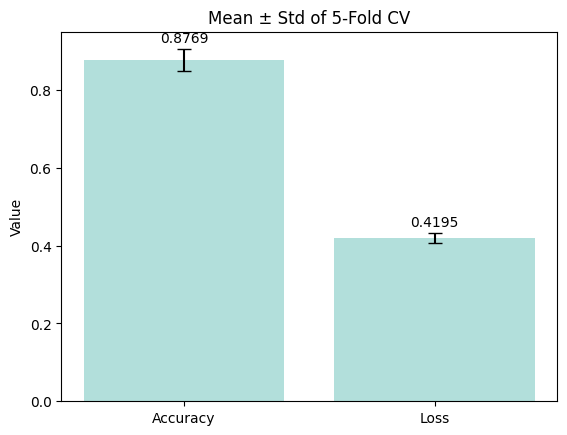

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Compute statistics
mean_acc  = np.mean(all_val_accs)
std_acc   = np.std(all_val_accs)
mean_loss = np.mean(all_val_losses)
std_loss  = np.std(all_val_losses)

# Plot
fig, ax = plt.subplots()
bars = ax.bar(
    ["Accuracy", "Loss"],
    [mean_acc, mean_loss],
    color="#B2DFDB",       # pastel teal
    yerr=[std_acc, std_loss],
    capsize=5
)
ax.set_title("Mean ± Std of 5-Fold CV")
ax.set_ylabel("Value")

# Annotate bars with exact values, placed above the error bars
stds = [std_acc, std_loss]
for bar, val, std in zip(bars, [mean_acc, mean_loss], stds):
    height = bar.get_height()
    # Position label above the error bar
    y = height + std + 0.01
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y,
        f"{val:.4f}",
        ha='center',
        va='bottom'
    )

plt.show()

In [36]:
import numpy as np
import pandas as pd

# Prepare a place to store your runs
cv_results = []

# After each 5-fold run (i.e. after you compute mean_acc, std_acc, mean_loss, std_loss):
#    pick a name for this architecture, e.g. 'multi_modal_cnn'
model_name = "simple_multi_modal_cnn"
mean_acc   = np.mean(all_val_accs)
std_acc    = np.std(all_val_accs)
mean_loss  = np.mean(all_val_losses)
std_loss   = np.std(all_val_losses)

cv_results.append({
    "model":       model_name,
    "mean_acc":    mean_acc,
    "std_acc":     std_acc,
    "mean_loss":   mean_loss,
    "std_loss":    std_loss
})

In [37]:
from sklearn.preprocessing import StandardScaler

# X_num_temp is the numeric data for your 85%—all of the folds combined.
scaler = StandardScaler()
X_num_temp_scaled = scaler.fit_transform(X_num_temp)

In [38]:
import tensorflow as tf
from tensorflow.keras import optimizers, callbacks

# Clear out any old model/graph
tf.keras.backend.clear_session()

# Rebuild your architecture
final_model = build_multi_modal(
    img_shape     = (300, 400, 3),
    num_num_feats = X_num_temp_scaled.shape[1],
    num_classes   = len(np.unique(y_all)),
    weight_decay  = 1e-4,
    dropout_rate  = 0.3
)

# Optimizer
sgd = optimizers.SGD(learning_rate=0.001, momentum=0.9, nesterov=True)

# Callbacks (reuse your LR schedule & early stopping)
epochs, batch_size = 50, 32
cosine_decay = optimizers.schedules.CosineDecay(0.001, decay_steps=epochs)
lr_cb = callbacks.LearningRateScheduler(lambda epoch, lr: float(cosine_decay(epoch)), verbose=1)
early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, start_from_epoch=20, verbose=1)

# Compile
final_model.compile(optimizer=sgd,
                    loss="sparse_categorical_crossentropy",
                    metrics=["accuracy"])

In [39]:
history_final = final_model.fit(
    [X_img_temp, X_num_temp_scaled],  # both inputs
    y_temp,
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[lr_cb, early_stop],
    validation_split=0.1,    # optionally hold out a small val for monitoring
    verbose=2
)


Epoch 1: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 1/50


2025-08-21 06:52:09.194121: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmulti_modal_cnn/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


38/38 - 18s - loss: 1.1355 - accuracy: 0.4444 - val_loss: 1.2536 - val_accuracy: 0.3556 - lr: 0.0010 - 18s/epoch - 468ms/step

Epoch 2: LearningRateScheduler setting learning rate to 0.000999013427644968.
Epoch 2/50
38/38 - 3s - loss: 0.8998 - accuracy: 0.6725 - val_loss: 1.0232 - val_accuracy: 0.5852 - lr: 9.9901e-04 - 3s/epoch - 89ms/step

Epoch 3: LearningRateScheduler setting learning rate to 0.0009960574097931385.
Epoch 3/50
38/38 - 4s - loss: 0.7451 - accuracy: 0.7769 - val_loss: 0.8748 - val_accuracy: 0.6815 - lr: 9.9606e-04 - 4s/epoch - 111ms/step

Epoch 4: LearningRateScheduler setting learning rate to 0.0009911436354741454.
Epoch 4/50
38/38 - 5s - loss: 0.6636 - accuracy: 0.8060 - val_loss: 0.7672 - val_accuracy: 0.7778 - lr: 9.9114e-04 - 5s/epoch - 138ms/step

Epoch 5: LearningRateScheduler setting learning rate to 0.0009842915460467339.
Epoch 5/50
38/38 - 4s - loss: 0.5869 - accuracy: 0.8549 - val_loss: 0.6842 - val_accuracy: 0.8667 - lr: 9.8429e-04 - 4s/epoch - 101ms/step


In [40]:
X_num_test_scaled = scaler.transform(X_num_test)

In [41]:
test_loss, test_acc = final_model.evaluate(
    [X_img_test, X_num_test_scaled],
    y_test,
    batch_size=32,
    verbose=1
)
print(f"Final test loss:     {test_loss:.4f}")
print(f"Final test accuracy: {test_acc:.4f}")

8/8 [==============================] - 0s 24ms/step - loss: 0.4231 - accuracy: 0.8945
Final test loss:     0.4231
Final test accuracy: 0.8945


In [42]:
# Option to save your trained model to disk (this line is commented out)
model_multi.save("simpleCNN_multi.keras")

# Load a previously saved model from disk
model_multi = keras.models.load_model("simpleCNN_multi.keras")

NameError: name 'model_multi' is not defined

In [43]:
# Save the training history (which is stored in a dictionary format) as a NumPy file.
np.save('simpleCNN_multi.npy', history.history)

In [44]:
df = np.load('simpleCNN_multi.npy', allow_pickle=True)
history_dict = df.item()
print(history_dict.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy', 'lr'])


In [45]:
# Load the saved training history from the NumPy file.
# 'allow_pickle=True' allows loading of the saved dictionary structure.
df = np.load('simpleCNN_multi.npy', allow_pickle=True)

# Convert the loaded dictionary (stored as a NumPy object) into a pandas DataFrame.
# The dictionary is accessed with .item() because np.load returns an ndarray when using allow_pickle.
# We're extracting specific keys: learning rate ('lr'), training loss ('loss'), training accuracy ('accuracy'),
# validation loss ('val_loss'), and validation accuracy ('val_accuracy').
df1 = pd.DataFrame({
    'lr': df.item()['lr'],
    'loss': df.item()['loss'],
    'accuracy': df.item()['accuracy'],
    'val_loss': df.item()['val_loss'],
    'val_accuracy': df.item()['val_accuracy']
})

# Print the first few rows of the DataFrame for inspection.
print(df1.head())

         lr      loss  accuracy  val_loss  val_accuracy
0  0.001000  1.102871  0.464119  1.286975      0.533582
1  0.000999  0.934415  0.643989  1.006689      0.626866
2  0.000996  0.798513  0.723206  0.886806      0.645522
3  0.000991  0.717136  0.766076  0.786176      0.705224
4  0.000984  0.640572  0.803355  0.730751      0.761194


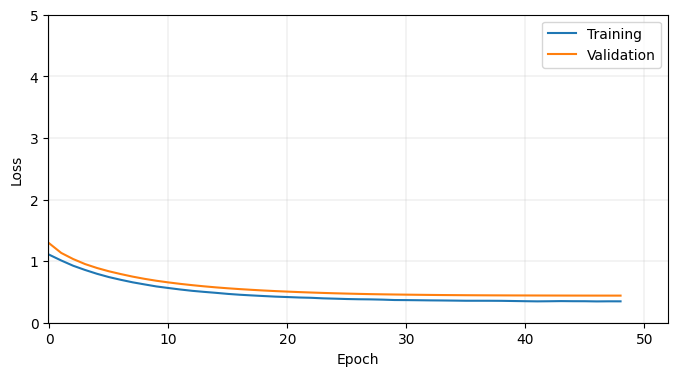

In [46]:
# Plot smoothed training and validation loss over epochs
plt.figure(figsize=(8,4))  # Create a new figure with a custom size (8 inches wide by 4 inches tall)

# Calculate and plot the exponentially weighted moving average (EWMA) of the training loss
ax = df1['loss'].ewm(span=10).mean().plot(label='Training')

# Calculate and plot the EWMA of the validation loss
ax = df1['val_loss'].ewm(span=10).mean().plot(label='Validation')
ax.set_xlabel('Epoch')  # Label the x-axis as 'Epoch'
ax.set_ylabel('Loss')   # Label the y-axis as 'Loss'
plt.grid(linewidth=0.2)  # Add a light grid for better readability
plt.ylim([0, 5.0])       # Set the y-axis limits to clearly show loss values
plt.xlim([-0.1, 52])    # Set the x-axis limits spanning epochs from near 0 to 400
plt.legend(loc='upper right')  # Place the legend in the upper right corner

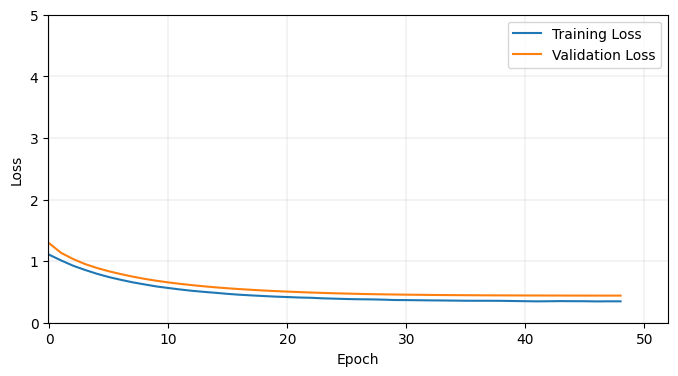

In [47]:
import matplotlib.pyplot as plt

# Create a new figure for the loss plot
plt.figure(figsize=(8, 4))

# Calculate exponentially weighted moving averages (EWMA)
training_loss_ewma = df1['loss'].ewm(span=10).mean()
validation_loss_ewma = df1['val_loss'].ewm(span=10).mean()

# Plot the training and validation loss curves
ax_loss = training_loss_ewma.plot(label='Training Loss')
validation_loss_ewma.plot(label='Validation Loss', ax=ax_loss)

# Customize plot appearance
ax_loss.set_xlabel('Epoch')
ax_loss.set_ylabel('Loss')
plt.grid(linewidth=0.2)
plt.ylim([0, 5.0])
plt.xlim([-0.1, 52])
plt.legend(loc='upper right')

# Save the figure as a PDF
plt.savefig("training_validation_loss_curve.pdf", format='pdf', bbox_inches='tight')

# Display the plot
plt.show()

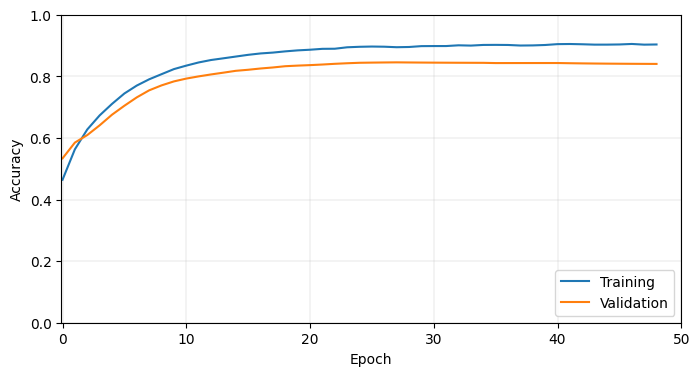

In [48]:
# Plot smoothed training and validation accuracy over epochs
plt.figure(figsize=(8,4))  # Create a separate figure for accuracy

# Plot the EWMA for training accuracy
ax = df1['accuracy'].ewm(span=10).mean().plot(label='Training')

# Plot the EWMA for validation accuracy
ax = df1['val_accuracy'].ewm(span=10).mean().plot(label='Validation')
ax.set_xlabel('Epoch')     # Label the x-axis
ax.set_ylabel('Accuracy')  # Label the y-axis as 'Accuracy'
plt.grid(linewidth=0.2)    # Add gridlines to the plot
plt.ylim([0, 1])           # Accuracy is expressed as a value between 0 and 1
plt.xlim([-0.1, 50])      # Set the x-axis to span epochs 0 to 400
plt.legend(loc='lower right')  # Place the legend in the lower right corner

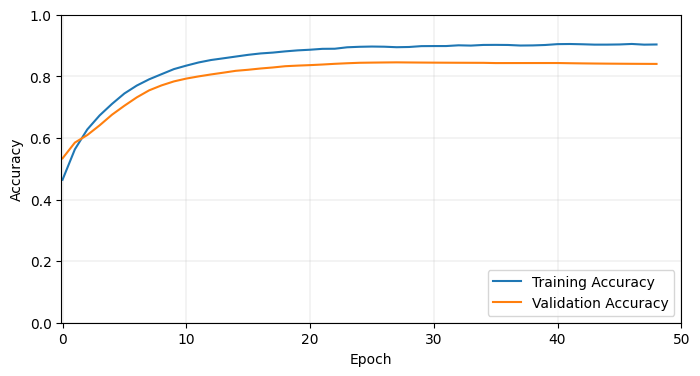

In [49]:
import matplotlib.pyplot as plt

# Create a new figure for the accuracy plot
plt.figure(figsize=(8, 4))

# Calculate exponentially weighted moving averages (EWMA)
training_accuracy_ewma = df1['accuracy'].ewm(span=10).mean()
validation_accuracy_ewma = df1['val_accuracy'].ewm(span=10).mean()

# Plot training and validation accuracy
ax_accuracy = training_accuracy_ewma.plot(label='Training Accuracy')
validation_accuracy_ewma.plot(label='Validation Accuracy', ax=ax_accuracy)

# Customize the plot
ax_accuracy.set_xlabel('Epoch')
ax_accuracy.set_ylabel('Accuracy')
plt.grid(linewidth=0.2)
plt.ylim([0, 1])
plt.xlim([-0.1, 50])
plt.legend(loc='lower right')

# Save as PDF
plt.savefig("training_validation_accuracy_curve.pdf", format='pdf', bbox_inches='tight')

# Show the plot (optional)
plt.show()

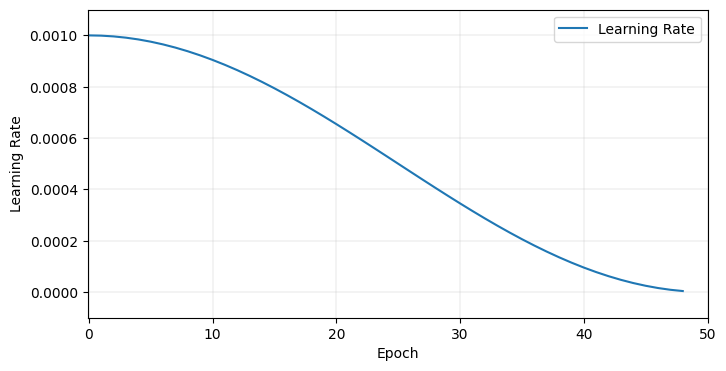

In [50]:
# Plot the learning rate over epochs (without smoothing)
plt.figure(figsize=(8,4))  # Create a new figure for the learning rate plot
ax = df1['lr'].plot(label='Learning Rate')  # Directly plot the learning rate values stored per epoch
ax.set_xlabel('Epoch')     # Label the x-axis as 'Epoch'
ax.set_ylabel('Learning Rate')  # Label the y-axis as 'Learning Rate'
plt.grid(linewidth=0.2)    # Display a grid for ease of interpretation
plt.ylim([-0.0001, 0.0011])  # Set y-axis limits to zoom in on the learning rate range
plt.xlim([-0.1, 50])      # Set x-axis limits for 400 epochs
plt.legend(loc='upper right')  # Position the legend in the upper right corner

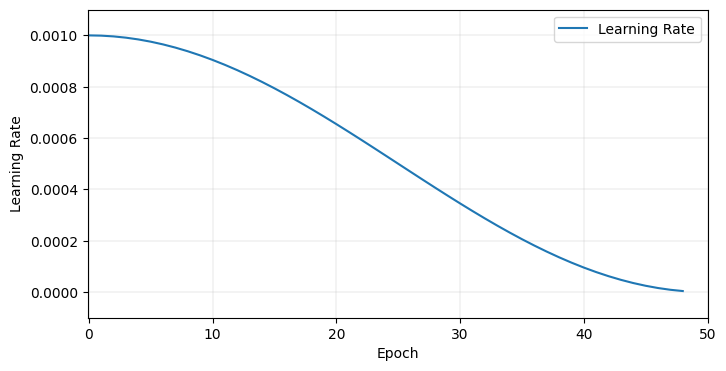

In [51]:
import matplotlib.pyplot as plt

# Create a new figure for the learning rate plot
plt.figure(figsize=(8, 4))

# Plot the learning rate values per epoch
ax_lr = df1['lr'].plot(label='Learning Rate')

# Customize axes and grid
ax_lr.set_xlabel('Epoch')
ax_lr.set_ylabel('Learning Rate')
plt.grid(linewidth=0.2)
plt.ylim([-0.0001, 0.0011])
plt.xlim([-0.1, 50])
plt.legend(loc='upper right')

# Save the figure as a PDF
plt.savefig("learning_rate_schedule.pdf", format='pdf', bbox_inches='tight')

# Optionally show the plot
plt.show()

8/8 [==============================] - 0s 18ms/step


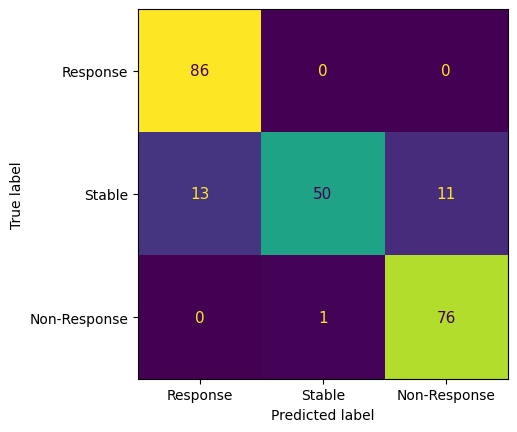

In [52]:
# 1) Predict with the final_model and properly scaled numeric input:
y_pred = final_model.predict([X_img_test, X_num_test_scaled],
                             batch_size=32,
                             verbose=1)

# 2) Convert to class labels
predictions = np.argmax(y_pred, axis=-1)

# 3) Compute and plot confusion matrix
cf_matrix = confusion_matrix(y_test, predictions)
cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cf_matrix,
    display_labels=['Response','Stable','Non-Response']
)
cm_display.plot(colorbar=False, text_kw={'fontsize':11})
plt.show()

8/8 [==============================] - 0s 17ms/step


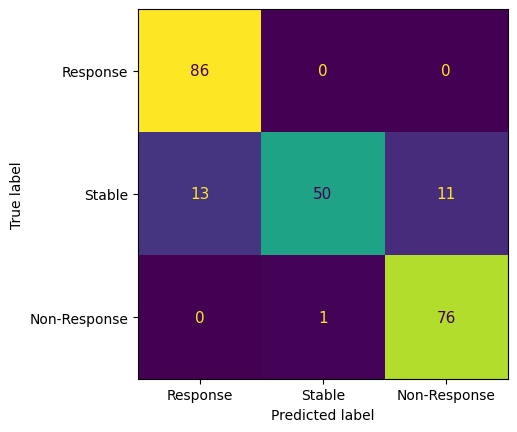

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# 1) Predict with the final_model and properly scaled numeric input:
y_pred = final_model.predict([X_img_test, X_num_test_scaled],
                             batch_size=32,
                             verbose=1)

# 2) Convert to class labels
predictions = np.argmax(y_pred, axis=-1)

# 3) Compute and plot confusion matrix
cf_matrix = confusion_matrix(y_test, predictions)
cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cf_matrix,
    display_labels=['Response', 'Stable', 'Non-Response']
)
cm_display.plot(colorbar=False, text_kw={'fontsize':11})

# Save the confusion matrix plot as a PDF
plt.savefig("confusion_matrix_plot.pdf", format='pdf', bbox_inches='tight')

# Show the plot (optional)
plt.show()

In [54]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions,
      target_names=['Response','Stable','Non-Response']))

              precision    recall  f1-score   support

    Response       0.87      1.00      0.93        86
      Stable       0.98      0.68      0.80        74
Non-Response       0.87      0.99      0.93        77

    accuracy                           0.89       237
   macro avg       0.91      0.89      0.89       237
weighted avg       0.91      0.89      0.89       237



In [55]:
import numpy as np

# Get predicted probabilities
y_score = final_model.predict([X_img_test, X_num_test_scaled])

# Save for future ROC plotting
np.savez("model_v1_predictions.npz", y_test=y_test, y_score=y_score)

8/8 [==============================] - 0s 16ms/step


8/8 [==============================] - 0s 19ms/step


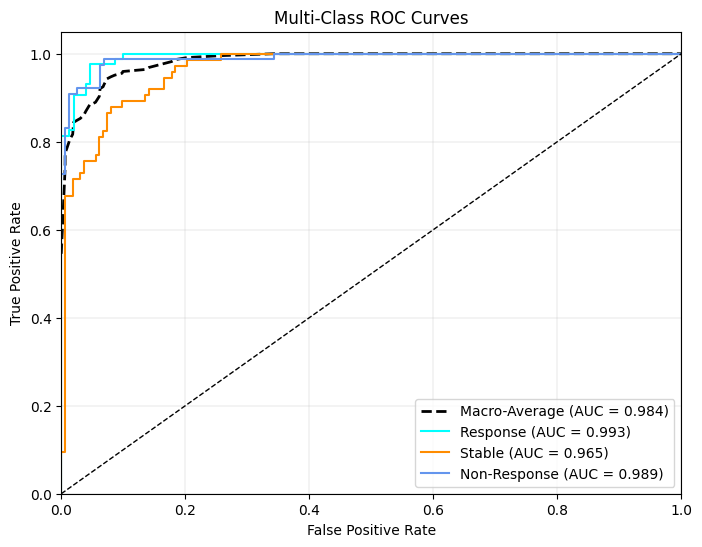

In [56]:
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Define human-readable labels
class_names = ['Response', 'Stable', 'Non-Response']

# Binarize true labels (one-hot)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Predict class probabilities
y_score = final_model.predict([X_img_test, X_num_test_scaled])

# Compute ROC curve and AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute macro-average ROC curve and AUC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
roc_auc["macro"] = auc(all_fpr, mean_tpr)

# Plot ROC curves
plt.figure(figsize=(8,6))
plt.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-Average (AUC = {roc_auc["macro"]:.3f})',
         color='black', linestyle='--', linewidth=2)

# Individual ROC curves
colors = ['aqua','darkorange','cornflowerblue']
for i, color in enumerate(colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curves')
plt.grid(linewidth=0.2)
plt.legend(loc='lower right')

# Save to PDF
plt.savefig("roc_curve_multiclass.pdf", format='pdf', bbox_inches='tight')
plt.show()

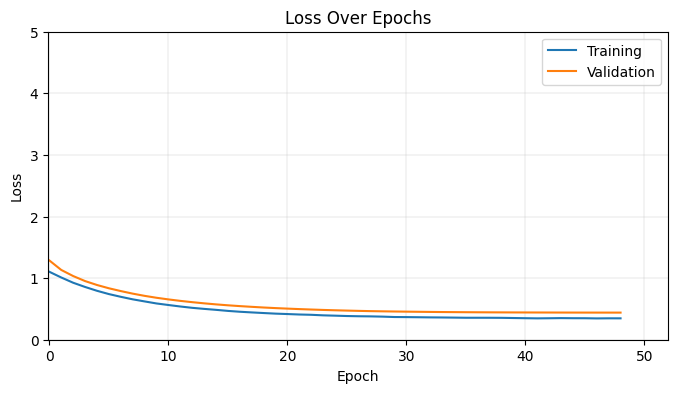

In [57]:
plt.figure(figsize=(8,4))
ax = df1['loss'].ewm(span=10).mean().plot(label='Training')
df1['val_loss'].ewm(span=10).mean().plot(label='Validation', ax=ax)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
plt.grid(linewidth=0.2)
plt.ylim([0, 5.0])
plt.xlim([-0.1, 52])
plt.legend(loc='upper right')
plt.title("Loss Over Epochs")
plt.savefig("loss_plot.pdf")
plt.show()

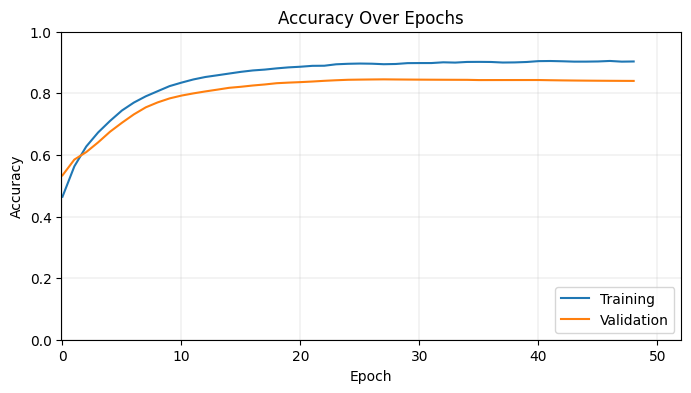

In [58]:
plt.figure(figsize=(8,4))
ax = df1['accuracy'].ewm(span=10).mean().plot(label='Training')
df1['val_accuracy'].ewm(span=10).mean().plot(label='Validation', ax=ax)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
plt.grid(linewidth=0.2)
plt.ylim([0, 1])
plt.xlim([-0.1, 52])
plt.legend(loc='lower right')
plt.title("Accuracy Over Epochs")
plt.savefig("accuracy_plot.pdf")
plt.show()

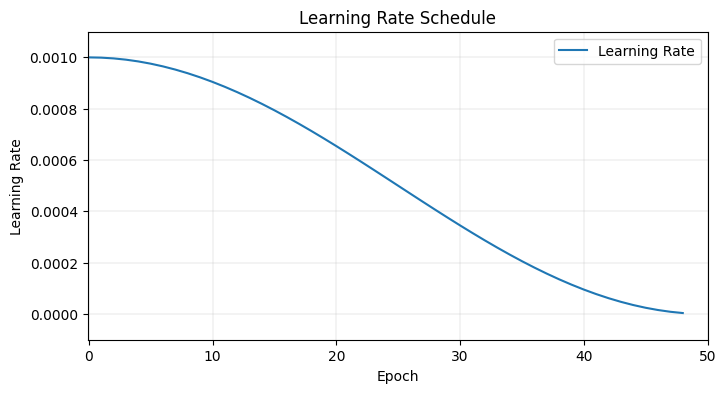

In [59]:
plt.figure(figsize=(8,4))
ax = df1['lr'].plot(label='Learning Rate')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
plt.grid(linewidth=0.2)
plt.ylim([-0.0001, 0.0011])
plt.xlim([-0.1, 50])
plt.legend(loc='upper right')
plt.title("Learning Rate Schedule")
plt.savefig("learning_rate_plot.pdf")
plt.show()

8/8 [==============================] - 0s 18ms/step


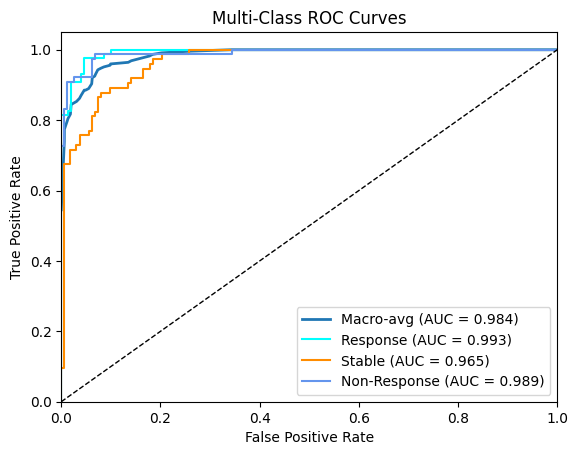

In [60]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

class_names = ['Response', 'Stable', 'Non-Response']
y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_score = final_model.predict([X_img_test, X_num_test_scaled])
n_classes = y_test_bin.shape[1]

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro-average
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = sum(np.interp(all_fpr, fpr[i], tpr[i]) for i in range(n_classes)) / n_classes
fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
roc_auc["macro"] = auc(all_fpr, mean_tpr)

plt.figure()
plt.plot(fpr["macro"], tpr["macro"], label=f'Macro-avg (AUC = {roc_auc["macro"]:.3f})', linewidth=2)
colors = ['aqua','darkorange','cornflowerblue']
for i, color in enumerate(colors):
    plt.plot(fpr[i], tpr[i], color=color, label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')

plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlim(0,1)
plt.ylim(0,1.05)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curves')
plt.legend(loc='lower right')
plt.savefig("roc_curve.pdf")
plt.show()

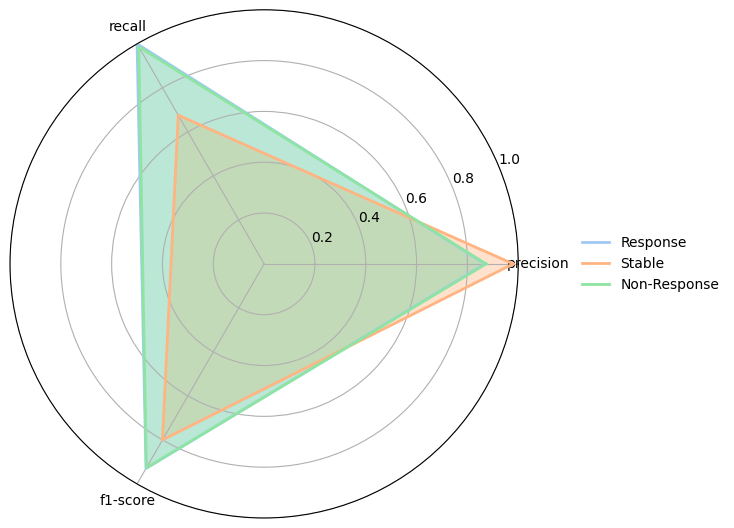

In [61]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

# Compute classification metrics
report_dict = classification_report(y_test, predictions, output_dict=True, target_names=class_names)
metrics = ['precision', 'recall', 'f1-score']
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]  # Close the loop

# Define pastel colors for each class
pastel_colors = ['#a1c9f4', '#ffb482', '#8de5a1']  # Light blue, peach, light green

# Create radar plot
fig, ax = plt.subplots(figsize=(7, 6), subplot_kw=dict(polar=True))

for i, label in enumerate(class_names):
    values = [report_dict[label][metric] for metric in metrics]
    values += values[:1]  # Loop back to the start
    ax.plot(angles, values, label=label, color=pastel_colors[i], linewidth=2)
    ax.fill(angles, values, color=pastel_colors[i], alpha=0.4)

# Configure axes
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)

# Move legend outside to the right
ax.legend(loc='center left', bbox_to_anchor=(1.1, 0.5), frameon=False)

# Save as PDF
plt.tight_layout()
plt.savefig("radar_metrics_filled.pdf", bbox_inches='tight')
plt.show()

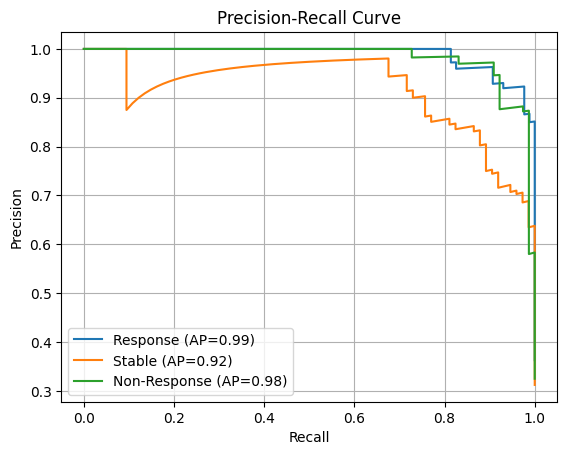

In [62]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

plt.figure()
for i in range(len(class_names)):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_score[:, i])
    plt.plot(recall, precision, label=f"{class_names[i]} (AP={ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.savefig("precision_recall_curve.pdf", bbox_inches='tight')
plt.show()

In [63]:
!pip install umap-learn seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 1.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 5.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 25.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 64.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 56.5 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 58.1 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
  Attem

In [65]:
import umap
import seaborn as sns

ImportError: cannot import name 'get_tags' from 'sklearn.utils' (/usr/local/lib/python3.11/dist-packages/sklearn/utils/__init__.py)

In [66]:
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

# Get features from your model
features = model.predict([X_img_test, X_num_test_scaled])

# t-SNE dimensionality reduction to 2D
X_tsne = TSNE(n_components=2, random_state=42).fit_transform(features)

# Plotting
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_test, palette='pastel')
plt.title("t-SNE Projection of Test Set")
plt.grid(True, linewidth=0.2)  # Add grid lines
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title='Class', loc='best')
plt.savefig("tsne_projection_pastel.pdf", bbox_inches='tight')  # Save as PDF
plt.show()

ImportError: cannot import name 'validate_data' from 'sklearn.utils.validation' (/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py)

In [67]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

def make_gradcam_heatmap(img_array, num_array, model, last_conv_layer_name, pred_index=None):
    # Build a model that maps image input to the last conv layer + output
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    # Record gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model([img_array, num_array])
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Compute gradients
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize to [0, 1]
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

In [68]:
final_model.summary()

Model: "multi_modal_cnn"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 image_input (InputLayer)    [(None, 300, 400, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 300, 400, 32)         896       ['image_input[0][0]']         
                                                                                                  
 batch_normalization (Batch  (None, 300, 400, 32)         128       ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 300, 400, 32)         0         ['batch_normaliz

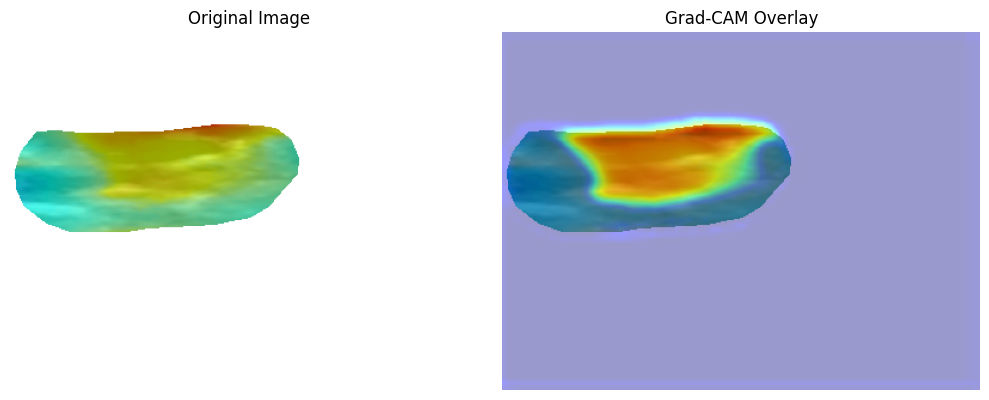

In [69]:
# Choose a test sample
img_idx = 0

# Prepare image and numeric input
img_input = X_img_test[img_idx:img_idx+1]
num_input = X_num_test_scaled[img_idx:img_idx+1]
img_orig = X_img_test[img_idx]

# Use your last conv layer
last_conv_layer = 'conv2d_4'

# Compute Grad-CAM heatmap
heatmap = make_gradcam_heatmap(img_input, num_input, final_model, last_conv_layer)

# Resize and overlay
heatmap_resized = cv2.resize(heatmap, (img_orig.shape[1], img_orig.shape[0]))
heatmap_rgb = np.uint8(255 * plt.cm.jet(heatmap_resized)[:, :, :3])
overlay = cv2.addWeighted(img_orig.astype(np.uint8), 0.6, heatmap_rgb, 0.4, 0)

# Plot and save
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_orig.astype(np.uint8))
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(overlay)
plt.title("Grad-CAM Overlay")
plt.axis('off')

plt.tight_layout()
plt.savefig(f'gradcam_sample{img_idx}.pdf', bbox_inches='tight')
plt.show()

In [75]:
import numpy as np

# ---- 1) For the .npz file (dictionary-like container) ----
data_v1 = np.load("model_v1_predictions.npz")

print("Keys in model_v1_predictions.npz:", data_v1.files)

for k in data_v1.files:
    arr = data_v1[k]
    print(f"{k}: shape={arr.shape}, dtype={arr.dtype}")
    # Peek at first few entries
    print(arr[:5])
    print("---")

# Example: maybe it has ["y_true", "y_pred", "y_score"]


# ---- 2) For the .npy file (single array only) ----
import numpy as np

# Load as pickled object and unwrap
mm_simple = np.load("multimodal_simple.npy", allow_pickle=True)
print("Raw shape:", mm_simple.shape, "dtype:", mm_simple.dtype)

if mm_simple.shape == () and mm_simple.dtype == object:
    mm_simple = mm_simple.item()
    print("Unwrapped type:", type(mm_simple))
    if isinstance(mm_simple, dict):
        print("Keys:", list(mm_simple.keys()))
        # Peek common possibilities
        for k in ["y_test", "y_score", "y_pred", "loss", "accuracy", "val_loss", "val_accuracy", "lr"]:
            if k in mm_simple:
                v = mm_simple[k]
                try:
                    print(f"  {k}: shape={np.asarray(v).shape}, dtype={np.asarray(v).dtype}")
                except Exception:
                    print(f"  {k}: type={type(v)}")
    else:
        print("Contents are not a dict. Type:", type(mm_simple))
else:
    print("File is not an object/dict container. Contents type:", type(mm_simple))

Keys in model_v1_predictions.npz: ['y_test', 'y_score']
y_test: shape=(237,), dtype=float32
[2. 0. 1. 0. 1.]
---
y_score: shape=(237, 3), dtype=float32
[[2.2924892e-03 4.7417805e-02 9.5028967e-01]
 [9.9540967e-01 4.3900521e-03 2.0024562e-04]
 [1.5515722e-01 6.9042665e-01 1.5441610e-01]
 [9.4166374e-01 4.5693524e-02 1.2642771e-02]
 [6.1935503e-02 6.1668098e-01 3.2138351e-01]]
---
Raw shape: () dtype: object
Unwrapped type: <class 'dict'>
Keys: ['loss', 'accuracy', 'val_loss', 'val_accuracy', 'lr']
  loss: shape=(49,), dtype=float64
  accuracy: shape=(49,), dtype=float64
  val_loss: shape=(49,), dtype=float64
  val_accuracy: shape=(49,), dtype=float64
  lr: shape=(49,), dtype=float32


In [77]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.000     0.000     0.000        86
           1      0.000     0.000     0.000        74
           2      0.325     1.000     0.490        77

    accuracy                          0.325       237
   macro avg      0.108     0.333     0.163       237
weighted avg      0.106     0.325     0.159       237



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  Asymptotically, `beta -> +inf` considers only recall, and `beta -> 0`
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  Asymptotically, `beta -> +inf` considers only recall, and `beta -> 0`
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  Asymptotically, `beta -> +inf` considers only recall, and `beta -> 0`
